# The Faraday delay template — results paper trail

**Takeaway.** LuSEE can measure the *shape* of the Galactic Faraday
depth distribution at 30 MHz. Whether it detects it at all is decided
by the interstellar medium's depolarisation floor — not by the
instrument, the noise, or the integration time.

This notebook is the paper trail for the `faraday-delay-template`
branch (PR #4). It loads the analysis products in `generated_data/`
and rebuilds every figure by calling `scripts/step5_plots.py`
directly, so the pictures below are the same objects the paper uses
rather than a second copy of the plotting code that can drift from it.
Nothing here re-runs the heavy jobs; §13 says how to.

Four claims carry the argument:

1. **The 2026-08-18 audit is answered on the point it attacked.** The
   refuted diffuse result was pixelisation shot noise. Binning the
   beam-weighted sky *in Faraday depth first* and transforming second
   gives a shape that is stable under refinement, and the
   incoherent-limit identity behind it checks independently at 1.069.
2. **30 MHz is the band.** It is the only one where Faraday resolution
   and depth reach line up, and it hosts the template's 90%-mass knee.
3. **Detectability turns on one physics unknown.** The tail gate opens
   at 30 and 50 MHz if the diffuse amplitude sits at the uniform-slab
   depolarisation floor and closes at every band if it sits at the
   internal-dispersion floor. That is a screen-geometry question, not
   an instrument or integration question.
4. **Two things this map cannot decide** — the amplitude bracket's
   upper end and sky domination at 50 MHz — are stated as
   indeterminate rather than quoted as values.

Read `docs/measurement-model.md` §9–§12 for the physics behind each.

In [1]:
import io
import subprocess
import sys
import time
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
from IPython.display import Image, Markdown, display

REPO = Path.cwd()
if REPO.name == "notebooks":
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "scripts"))

# common sets JAX_ENABLE_X64=1 before anything pulls jax in, and puts
# src/ on the path.  step5_plots imports it too; importing it here
# first makes the ordering explicit rather than incidental.
import common  # noqa: E402
import step5_plots as sp  # noqa: E402
from common import GEN_DIR  # noqa: E402

from lusee_faraday import dispersion as dsp  # noqa: E402
from lusee_faraday.conventions import lambda_squared  # noqa: E402


def show(fig, pad=0.25, dpi=140):
    """Render a figure to an inline PNG, backend-independently.

    step5_plots selects the Agg backend at import (it is a script
    module), so the usual inline-figure formatter is not registered.
    Rasterising here and displaying works either way, and it is what
    puts the pictures inside the committed .ipynb.

    This DISPLAYS rather than returning the Image: returning it means
    a figure is silently dropped whenever the call is not the cell's
    last expression, which is exactly what happened to the knee/tail
    figure in section 9.
    """
    buf = io.BytesIO()
    fig.savefig(
        buf, format="png", dpi=dpi, bbox_inches="tight", pad_inches=pad
    )
    sp.plt.close(fig)
    display(Image(data=buf.getvalue()))


def table(rows, header):
    """Render a list of rows as a markdown table."""
    out = ["| " + " | ".join(header) + " |",
           "|" + "|".join(["---"] * len(header)) + "|"]
    out += ["| " + " | ".join(str(c) for c in r) + " |" for r in rows]
    return Markdown("\n".join(out))


def _human(n):
    return f"{n / 1e6:.1f} MB" if n >= 1e6 else f"{n / 1e3:.1f} kB"


PRODUCTS = {
    "template (four-port)": "step5_template.npz",
    "template (two-port)": "step5_template_two_port.npz",
    "sensitivity": "step5_sensitivity.npz",
    "instrument envelope": "step5_envelope.npz",
}
missing = [v for v in PRODUCTS.values() if not (GEN_DIR / v).exists()]
if missing:
    raise SystemExit(
        "missing analysis products in generated_data/: "
        + ", ".join(missing)
        + "\nThey are gitignored (regenerable, and 25 MB each). "
        "See section 13 for the commands that rebuild them."
    )

d = np.load(GEN_DIR / "step5_template.npz")
d2 = np.load(GEN_DIR / "step5_template_two_port.npz")
s = np.load(GEN_DIR / "step5_sensitivity.npz")
env = np.load(GEN_DIR / "step5_envelope.npz")

BANDS = d["bands"]                      # [30, 50, 10] MHz
KS = d["ks"]                            # [100, 0, -1]; k=0 is fiducial
K_FID = int(np.argmin(np.abs(KS - 0.0)))

head = subprocess.run(
    ["git", "-C", str(REPO), "rev-parse", "--short", "HEAD"],
    capture_output=True, text=True,
).stdout.strip()
branch = subprocess.run(
    ["git", "-C", str(REPO), "rev-parse", "--abbrev-ref", "HEAD"],
    capture_output=True, text=True,
).stdout.strip()

rows = [
    (
        name,
        f"`{fn}`",
        datetime.fromtimestamp(
            (GEN_DIR / fn).stat().st_mtime, timezone.utc
        ).strftime("%Y-%m-%d %H:%M UTC"),
        _human((GEN_DIR / fn).stat().st_size),
    )
    for name, fn in PRODUCTS.items()
]
display(Markdown(f"**Branch** `{branch}` at `{head}`  |  "
                 f"**bands** {', '.join(f'{b:.0f}' for b in BANDS)} MHz  |  "
                 f"**fiducial geometry** k = {KS[K_FID]:.0f} (uniform slab)"))
display(table(rows, ["product", "file", "written", "size"]))

**Branch** `faraday-delay-template` at `6d91f31`  |  **bands** 30, 50, 10 MHz  |  **fiducial geometry** k = 0 (uniform slab)

| product | file | written | size |
|---|---|---|---|
| template (four-port) | `step5_template.npz` | 2026-08-21 02:49 UTC | 25.6 MB |
| template (two-port) | `step5_template_two_port.npz` | 2026-08-21 03:14 UTC | 25.6 MB |
| sensitivity | `step5_sensitivity.npz` | 2026-08-21 16:15 UTC | 3.0 kB |
| instrument envelope | `step5_envelope.npz` | 2026-08-21 03:21 UTC | 1.9 kB |

## 1. What the audit refuted

The previous diffuse calculation summed the Faraday phasor pixel by
pixel,

$$P(\lambda^2) \;=\; \sum_n w_n\, e^{2 i \phi_n \lambda^2},$$

and read an amplitude off the result. At nside 512 the Faraday depth
moves by order $10^3$ rad between neighbouring pixels, so at 30 MHz
($\lambda^2 \approx 99.9\ \mathrm{m}^2$) the phase advances many turns
from one pixel to the next. The sum is then a **random walk**: its
magnitude scales as $1/\sqrt{N_{\rm pix}}$ and carries no sky
information at all. That is the 2026-08-18 audit's finding, and it is
the reason the Step 2 and Step 4 results live only on the
`audit-2026-08-18` tag and were not carried onto `main`.

The cell below is a synthetic illustration of the mechanism — not the
real sky, and not evidence about it. It draws $\phi_n$ from a Gaussian
and shows the mean phasor collapsing on the $N^{-1/2}$ line.

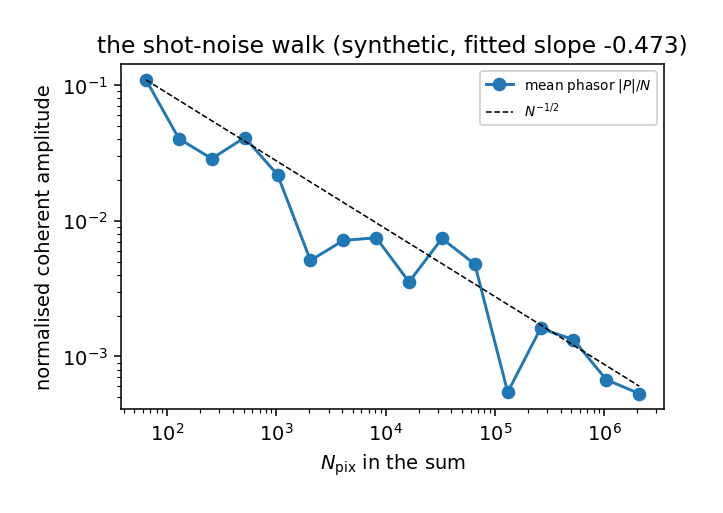

In [2]:
lam2_30 = float(lambda_squared(30.0)[0])
sigma_rm = 100.0                      # rad/m^2, order of the real sky
rng = np.random.default_rng(0)

n_max = 2 ** 21
phi_synth = rng.normal(0.0, sigma_rm, n_max)
ns = np.array([2 ** k for k in range(6, 22)])
amp = np.array(
    [abs(np.exp(2j * phi_synth[:n] * lam2_30).mean()) for n in ns]
)
slope = np.polyfit(np.log(ns), np.log(amp), 1)[0]

fig, ax = sp.plt.subplots(figsize=(5, 3.2))
ax.loglog(ns, amp, "o-", label="mean phasor $|P|/N$")
ax.loglog(ns, amp[0] * (ns / ns[0]) ** -0.5, "k--", lw=0.8,
          label=r"$N^{-1/2}$")
ax.set(xlabel=r"$N_{\rm pix}$ in the sum",
       ylabel="normalised coherent amplitude",
       title=f"the shot-noise walk (synthetic, fitted slope {slope:.3f})")
ax.legend(fontsize=7)
show(fig)

## 2. The fix: bin in depth first, transform second

Reverse the order of operations. Bin the beam- and
emissivity-weighted sky by Faraday depth to get the depth distribution
$F(\phi)$, *then* transform:

$$P(\lambda^2) \;=\; \int F(\phi)\, e^{2 i \phi \lambda^2}\, d\phi .$$

$F(\phi)$ is a histogram, so its **shape** is invariant under
pixelisation refinement; only its normalisation carries the shot
noise. That is the whole design of `dispersion.py`, and why it
converges where the pixel-by-pixel coherent sum does not
(`docs/measurement-model.md` §9). Both directions use **type-3
NUFFTs on the true $\lambda^2$ nodes** — never an FFT on a uniform
$\nu$ grid (§8 below shows why). The beam weight itself is
basis-independent, combining both Faraday branches of the pair-Stokes
kernel as $\sqrt{\tfrac12(|K_Q|^2 + |K_U|^2)}$ rather than one branch
alone.

Two different claims are at stake, and they are pinned by two
different tests.

**(a) The model's shape is pixelisation-stable.** The normalised
$F(\phi)$ moves by CDF distances of 2e-5 to 1.9e-4 across nside
256–2048 and under a rigid null rotation, against a 1e-2 tolerance,
while the old coherent power collapses 8.42e-07 → 6.26e-09 over the
same 64× refinement — a factor 134 — and moved by 7.2× under the
rotation alone.
*Pinned by* `tests/test_dispersion_gates.py::test_gate1_shape_invariance_under_refinement`
and `::test_gate2_shape_invariance_under_null_rotation`.

**(b) The observable equals the weighted depth distribution.** This is
the load-bearing claim, and the gates in (a) do **not** test it: with
the uniform weights those gates use, a rigid rotation is a pixel
permutation that leaves the statistic invariant by construction, and
the nside 1024/2048 legs are interpolated upsamplings carrying no new
sky. It is tested directly instead — the delay power of the *coherent
pixel sum*, with real WMAP K polarisation angles as the pixel phases,
against `depth_distribution`. Measured at 30 MHz: **1.069** over
$30 \le |\phi| < 1500$, and 1.332 over the whole axis.
*Pinned by* `::test_delay_power_equals_the_weighted_depth_distribution`.

Read 1.069 as an **independent confirmation that the ratio is
consistent with unity**, not as a reproduction of the audit's 1.038:
different window, grid and estimator, and the audit's own number is
one of a series running 1.010 / 1.184 / 1.038 / 0.843 across nside
with ~13% scatter. What it adds is a second estimator, built from
different machinery, landing in the same place.

It is a test rather than an identity — falsification probes break it
(`k=0` geometry gives 1.85, a shuffled RM map 1.58, and the
`RM × 0.02` converged control fails by >1e4) — but two limits are
worth stating explicitly:

- It does **not** demonstrate that the sky is incoherent. Setting
  $c = |c|$, every pixel phase identical and maximally coherent,
  still passes at 0.889, because one turn of the carrier is a depth
  separation of only $\pi/\lambda^2 = 0.0315$ rad/m² at 30 MHz.
- It does not pass merely because WMAP K noise randomises the phases:
  smoothing $Q$ and $U$ to 3° and 10° gives 1.107 and 1.143.

## 3. The template family

The deliverable is a **normalised shape**, one per band per geometry.
The geometry knob is $\rho(f) \sim f^k$, the emissivity profile along
the line of sight: $k \to \infty$ puts all emission behind the full
rotating column, $k = 0$ is the uniform slab (fiducial), $k \to -1$
puts it all in front. Solid curves are the incoherent template;
dotted curves are the coherent bracket companion. Grey verticals are
the beam-weighted $|RM|$ percentiles of the sky.

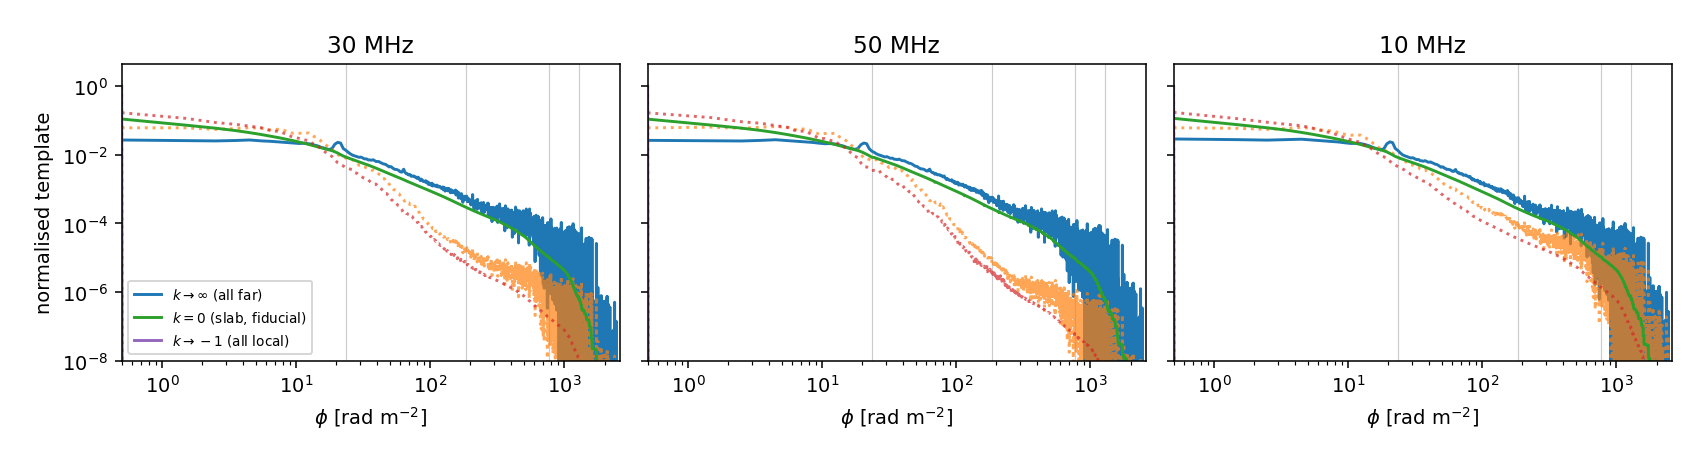

In [3]:
show(sp.fig_template_family(d))

## 4. What "beam-weighted" means

The template is not a histogram of the RM map. Every pixel enters
weighted by $|w|^2$ — the LST- and pair-averaged Faraday response of
the as-built four-port instrument, sampled out of a frozen kernel by
`response.pair_weight_maps`. That weight is what makes the sky
percentiles in §3 and §7 *beam-weighted* rather than map percentiles,
and the difference is not cosmetic: beam weighting roughly doubles p90
and nearly triples p99 (see §7).

The grey cap carries **exactly zero** weight: sky that never rises
above the horizon at the landing site over the whole LST grid, so it
contributes to no template at any band. It is masked, not clipped.

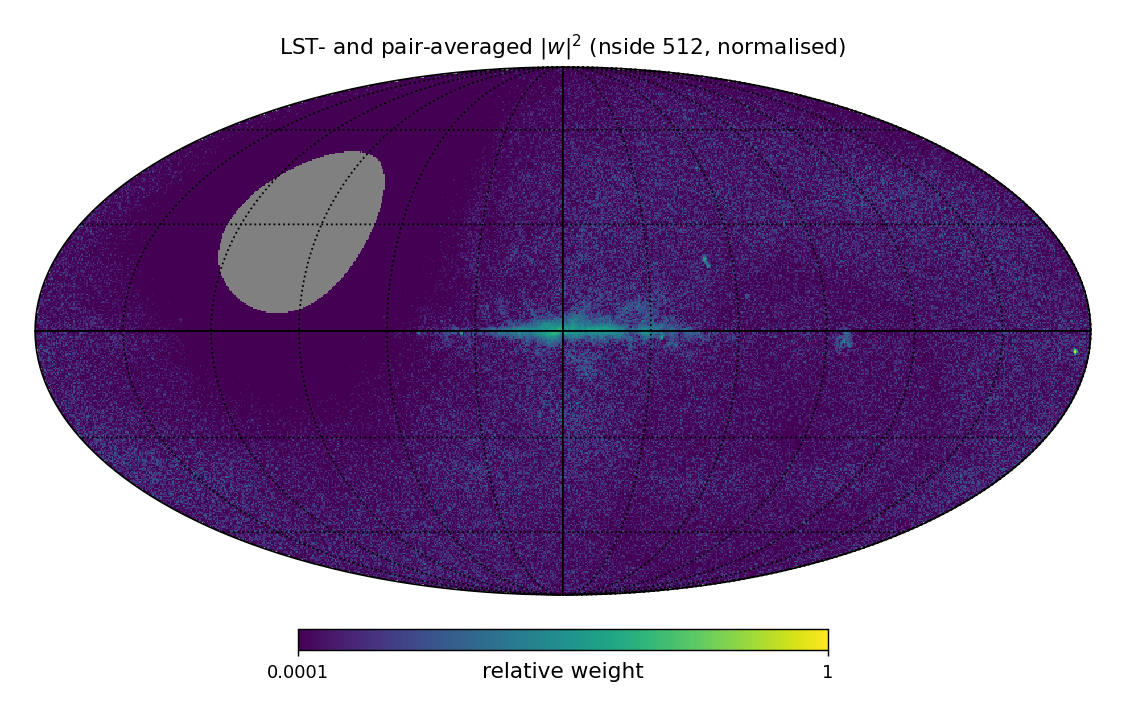

_4.2% of the sky (the grey cap) is never above the horizon over the LST grid and carries exactly zero weight. Colour scale is logarithmic and clipped at 1e-4 of the peak; the Galactic plane dominates, which is why the plane taper in §5 moves the knee so far._

In [4]:
w2 = d["w2_mean"]
show(sp.fig_weight_map(d), dpi=130)

n_zero = int((w2 <= 0).sum())
display(Markdown(
    f"_{100 * n_zero / w2.size:.1f}% of the sky (the grey cap) is never "
    f"above the horizon over the LST grid and carries exactly zero "
    f"weight. Colour scale is logarithmic and clipped at 1e-4 of the "
    f"peak; the Galactic plane dominates, which is why the plane taper "
    f"in §5 moves the knee so far._"
))

## 5. How robust the shape is

Two perturbations, both computed by `scripts/step5_template.py`,
neither a pass/fail:

- **Plane taper** (S4.2.1). Down-weighting the Galactic plane by
  $\sin^2|b|$ moves the 90%-mass knee by a large factor, so the
  roll-off is carried by the plane. That is the *unfavourable*
  branch: long in-plane paths are exactly where $B_\parallel$ reverses
  and the linear $\phi(f)$ ansatz is weakest, so the amplitude bracket
  in §10 must be read as **wider, not narrower**.
- **Two arms** (S4.9). Swapping the as-built four-port $|w|^2$ for the
  symmetric two-port one weights different declination strips. At the
  band that owns the knee, they agree.

The knee is `dispersion.mass_quantile_knee` — the 90% mass quantile of
the folded template, a CDF statistic, *not* a half-power crossing. An
earlier half-power version pinned to a narrow origin spike under the
$k=0$ slab geometry and was replaced for that reason.

| band | knee (k=0) | knee, plane-tapered | taper factor | two-port knee | arm swap |
|---|---|---|---|---|---|
| 30 MHz | 89.62 | 17.95 | 4.99x | 88.99 | -0.7% |
| 50 MHz | 83.32 | 19.26 | 4.33x | 103 | +23.6% |
| 10 MHz | 83.91 | 18.03 | 4.66x | 94.09 | +12.1% |

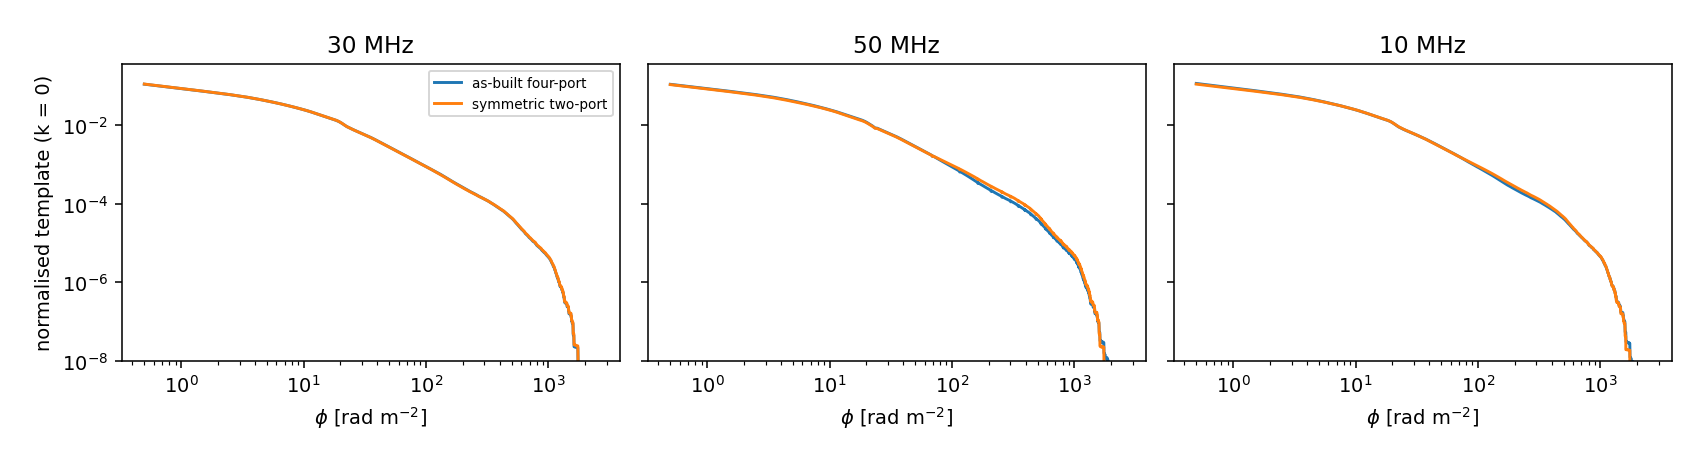

In [5]:
rows = []
for ib, band in enumerate(BANDS):
    kn = d["knee"][ib, K_FID]
    kt = d["knee_taper"][ib, K_FID]
    k2 = d2["knee"][ib, K_FID]
    rows.append((
        f"{band:.0f} MHz",
        f"{kn:.4g}",
        f"{kt:.4g}",
        f"{kn / kt:.2f}x",
        f"{k2:.4g}",
        f"{100 * (k2 - kn) / kn:+.1f}%",
    ))
display(table(rows, ["band", "knee (k=0)", "knee, plane-tapered",
                     "taper factor", "two-port knee", "arm swap"]))
show(sp.fig_two_arm(d, d2))

## 6. Three bands are three different problems

Faraday resolution is set by the span of $\lambda^2$ the zoom bins
actually cover — 192 zoom-bin centres spanning 74.6 kHz, not the fine
grid's 200 kHz. `dispersion.rmsf` builds the point-spread function
from luseepy's **true bin responses**, so this is cheap enough to
recompute here rather than quote.

Two conventions have to travel with the number or it is meaningless.
`dispersion.rmsf` returns **power**, so a width read straight off it
is a power FWHM; the conventional RM-synthesis resolution is an
**amplitude** FWHM, wider by $1/0.734$. The last column is the exact
half-power width of an ideal top-hat over the *same* span,
$2 \times 1.8955 / \Delta\lambda^2$.

In [6]:
def fwhm(x, y, level):
    """Interpolated full width at `level` x peak of a peaked curve."""
    y = np.asarray(y, float) / np.max(y)
    i = int(np.argmax(y))

    def cross(step):
        j = i
        while 0 <= j + step < y.size and y[j + step] >= level:
            j += step
        x0, x1, y0, y1 = x[j], x[j + step], y[j], y[j + step]
        return x0 + (level - y0) * (x1 - x0) / (y1 - y0)

    return cross(+1) - cross(-1)


t0 = time.time()
rows = []
for band, half in ((30.0, 40.0), (50.0, 150.0), (10.0, 2.0)):
    fine, bins, W = dsp.zoom_bin_matrix(band)
    phi_out = np.linspace(-half, half, 80001)
    p = dsp.rmsf(0.0, fine, W, bins, phi_out)
    # amplitude FWHM = full width where POWER falls to 0.25, since
    # amplitude = sqrt(power); computed directly, not via the 0.734
    # factor, so the two columns are independent measurements.
    dlam2 = np.ptp(np.asarray(lambda_squared(bins), float))
    rows.append((
        f"{band:.0f} MHz",
        f"{fwhm(phi_out, p, 0.5):.3f}",
        f"**{fwhm(phi_out, p, 0.25):.3f}**",
        f"{2 * 1.8955 / dlam2:.3f}",
    ))
display(table(rows, ["band", "power FWHM", "amplitude FWHM",
                     "ideal top-hat, same span"]))
display(Markdown(
    f"_All in rad/m². Computed live from `dispersion.rmsf` in "
    f"{time.time() - t0:.1f} s; matches `docs/measurement-model.md` "
    f"§10. The measured RMSF sits 0.5% below the ideal top-hat — the "
    f"$(n-1)/n$ correction for summing 192 discrete samples instead "
    f"of integrating — so **the real bin responses do not broaden the "
    f"RMSF at all**. They attenuate instead; that envelope is §7._"
))

| band | power FWHM | amplitude FWHM | ideal top-hat, same span |
|---|---|---|---|
| 30 MHz | 5.574 | **7.592** | 7.632 |
| 50 MHz | 25.805 | **35.150** | 35.334 |
| 10 MHz | 0.206 | **0.281** | 0.283 |

_All in rad/m². Computed live from `dispersion.rmsf` in 1.5 s; matches `docs/measurement-model.md` §10. The measured RMSF sits 0.5% below the ideal top-hat — the $(n-1)/n$ correction for summing 192 discrete samples instead of integrating — so **the real bin responses do not broaden the RMSF at all**. They attenuate instead; that envelope is §7._

Resolution alone ranks the bands the opposite way from usefulness.
10 MHz is sharpest and irrelevant — §7 shows its depth horizon falls
below the beam-weighted median sky depth, so there is nothing there
for that resolution to resolve. 50 MHz is coarsest but reaches
furthest. **30 MHz is where resolution and reach line up**: it hosts
the 90%-mass knee at ~90 rad/m², well inside its own 604 rad/m² zoom
horizon and about 12 resolution elements out from the origin spike.

## 7. Channel width is a Faraday-depth horizon

A spectrometer bin is a window in $\nu$, so in depth it acts as a
multiplicative envelope: the instrument imposes its own roll-off on
top of the sky's. The 50% depths below come from luseepy's real bin
responses, against the sky's **beam-weighted** $|RM|$ percentiles —
the same $|w|^2$ the templates are built from.

| band | parent horizon | zoom horizon |
|---|---|---|
| 50 MHz | 58.03 | 2796.9 |
| 30 MHz | 12.54 | 604.1 |
| 10 MHz | 0.46 | 22.4 |

| beam-weighted sky \|RM\| percentile | rad/m² |
|---|---|
| p50 | 23.4 |
| p90 | 185.7 |
| p99 | 776.1 |
| p99.9 | 1283.0 |
| map max | 2442.1 |

**No parent bin reaches the knee.** Parent horizons run 0.46–58.0 rad/m² while the fiducial knees sit at 83.3–89.6 rad/m² — every parent horizon is below every knee. Only the zoom bins reach, and only 50 MHz's zoom horizon clears the map maximum.

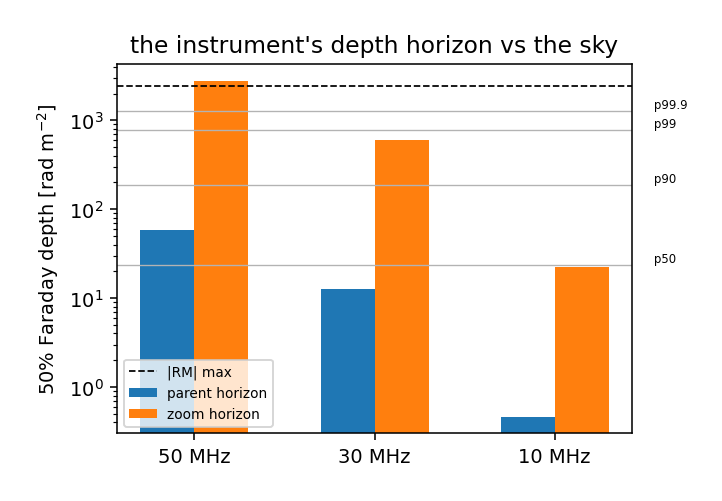

In [7]:
rows = []
for ib, band in enumerate(env["bands"]):
    rows.append((
        f"{band:.0f} MHz",
        f"{env['parent_horizon'][ib]:.2f}",
        f"{env['zoom_horizon'][ib]:.1f}",
    ))
display(table(rows, ["band", "parent horizon", "zoom horizon"]))
display(table(
    [(f"p{q:g}", f"{v:.1f}") for q, v in
     zip(env["percentile_qs"], env["percentiles"])]
    + [("map max", f"{float(env['rm_max']):.1f}")],
    ["beam-weighted sky \\|RM\\| percentile", "rad/m²"],
))
knees = d["knee"][:, K_FID]
display(Markdown(
    f"**No parent bin reaches the knee.** Parent horizons run "
    f"{env['parent_horizon'].min():.2f}–{env['parent_horizon'].max():.1f} "
    f"rad/m² while the fiducial knees sit at "
    f"{knees.min():.1f}–{knees.max():.1f} rad/m² — every parent horizon "
    f"is below every knee. Only the zoom bins reach, and only "
    f"50 MHz's zoom horizon clears the map maximum."
))
show(sp.fig_envelope(env))

## 8. Why a NUFFT, not an FFT

$\lambda^2$ is not uniform in $\nu$, so an FFT taken on a uniform
frequency grid smears a single Faraday depth into a chirp. That is an
**analysis artifact**, not a physical wall — it disappears entirely
under a type-3 NUFFT evaluated on the true $\lambda^2$ nodes. The
figure injects one tone at $\phi_0 = 600$ rad/m² and transforms it
both ways.
*Pinned by* `tests/test_dispersion.py::test_nufft_beats_fft_on_a_single_depth`.

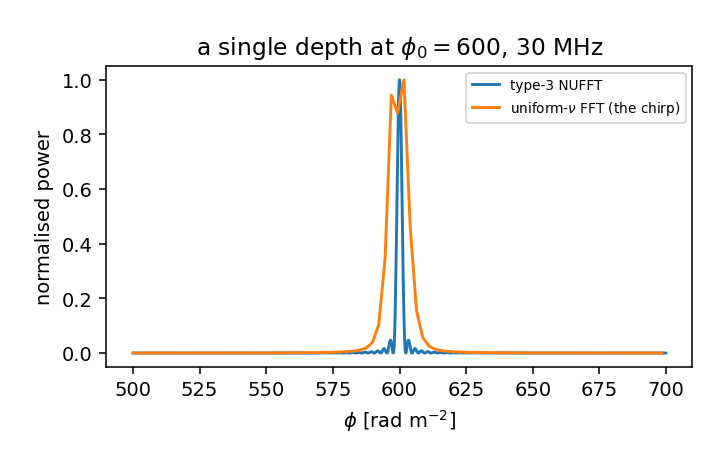

In [8]:
show(sp.fig_chirp_coherence())

## 9. The knee, and the tail that decides localisation

Left panel: the fraction of template power above the fixed
beam-weighted p99 threshold, resolved over LST across a full lunation.
It peaks sharply at Galactic Centre transit and falls to ~1e-6 away
from it. Right panel: the 90%-mass knee per band, with the
plane-tapered version overlaid.

Spec S4.2.2 separates *detection* from *localisation* by roughly the
square root of the tail's power fraction — the arithmetic §10 runs.

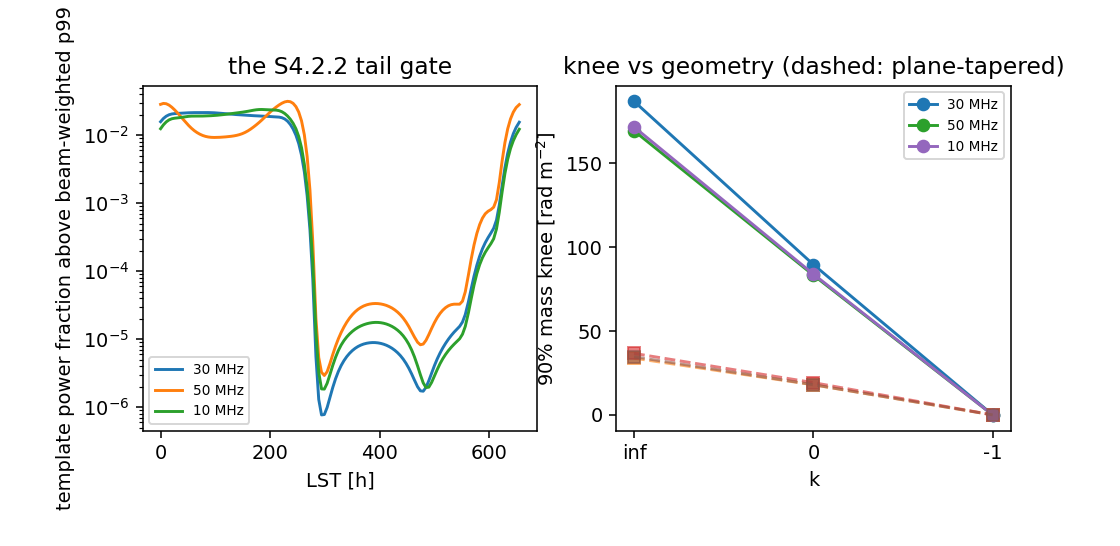

| band | GC-transit max | LST mean | two-port arm, transit max |
|---|---|---|---|
| 30 MHz | 2.16% | 0.81% | 2.18% |
| 50 MHz | 3.15% | 0.81% | 3.70% |
| 10 MHz | 2.39% | 0.82% | 2.69% |

In [9]:
show(sp.fig_knee_tail(d), pad=0.4)

f_max = d["tail_frac_lst"].max(axis=1)
f_mean = d["tail_frac_lst"].mean(axis=1)
rows = [
    (f"{b:.0f} MHz", f"{100 * f_max[i]:.2f}%", f"{100 * f_mean[i]:.2f}%",
     f"{100 * d2['tail_frac_lst'][i].max():.2f}%")
    for i, b in enumerate(BANDS)
]
display(table(rows, ["band", "GC-transit max", "LST mean",
                     "two-port arm, transit max"]))

## 10. The verdict

This is the branch's headline decision, so the cell below **derives**
it from the stored arrays rather than restating it.

The tail's *amplitude* is `bracket × sqrt(f)`, not `bracket × f` —
`tail_frac_lst` is a fraction of the template's **power** while the
bracket is an **amplitude**. That convention is worth 6.8× on every
ratio at 30 MHz, and an earlier version of the ledger lost it.

`dispersion.amplitude_bracket` returns three levels. Only two are
usable:

- `lower_slab` $= 1/(|\phi_{\rm med}| \lambda^2)$ — robust, $\theta_c$-free
- `lower_dispersion` $= 1/(2\sigma_{\rm eff}^2 \lambda^4)$ — robust, $\theta_c$-free
- `upper` — contains $\theta_c$, **not computable from this map** (§12),
  and therefore deliberately absent from the table below

Compared against the 5σ whitened matched-filter threshold at 24
lunations, on the zoom-bin covariance that carries the 1.44× ENBW
overlap rather than assuming independent modes.

In [10]:
i24 = int(np.where(s["lunations"] == 24)[0][0])
A_mf = s["A_mf"][:, i24]
f_tail = d["tail_frac_lst"].max(axis=1)          # GC transit, per band

def verdict(r):
    if r > 1:
        return f"**{r:.2f} OPEN**"
    return f"{r:.3f} closed" if r >= 1e-3 else f"{r:.1e} closed"


rows = []
for ib, band in enumerate(BANDS):
    upper, slab, disp = d["bracket"][ib]
    cells_ = [f"{band:.0f} MHz", f"{A_mf[ib]:.3g}", f"{100 * f_tail[ib]:.2f}%"]
    for level in (slab, disp):
        amp = level * np.sqrt(f_tail[ib])
        cells_ += [f"{amp:.3g}", verdict(amp / A_mf[ib])]
    rows.append(tuple(cells_))

display(table(rows, ["band", "A_mf (24 lun)", "tail f",
                     "tail amp @ slab", "ratio",
                     "tail amp @ dispersion", "ratio"]))

# The two-port arm taken CONSISTENTLY -- its own bracket against its
# own sqrt(f), never the four-port bracket -- as an arm cross-check on
# the OPEN/closed calls rather than on the ratios themselves.
f2 = d2["tail_frac_lst"].max(axis=1)
display(table(
    [(f"{b:.0f} MHz",
      verdict(d["bracket"][i, 1] * np.sqrt(f_tail[i]) / A_mf[i]),
      verdict(d2["bracket"][i, 1] * np.sqrt(f2[i]) / A_mf[i]))
     for i, b in enumerate(BANDS)],
    ["band", "four-port, slab floor", "two-port, slab floor"],
))

# How much more integration would close the 30 MHz dispersion-floor
# gap?  A ~ n^-1/2 N^-1/4 in n nights of N samples each; adding nights
# scales n alone, so the threshold falls as n^-1/2 and the gap costs
# gap**2 -- NOT gap**(4/3), which would be the cost if N grew with it.
ib30 = int(np.argmin(np.abs(BANDS - 30.0)))
gap = A_mf[ib30] / (d["bracket"][ib30, 2] * np.sqrt(f_tail[ib30]))
display(Markdown(
    f"At 30 MHz the internal-dispersion floor sits **{gap:.0f}x** below "
    f"the threshold. Adding nights scales the threshold as $n^{{-1/2}}$, "
    f"so closing that gap by integration alone would take "
    f"~{gap ** 2:.0e} times more nights. **Integration is not the lever.**"
))

| band | A_mf (24 lun) | tail f | tail amp @ slab | ratio | tail amp @ dispersion | ratio |
|---|---|---|---|---|---|---|
| 30 MHz | 1.33e-05 | 2.16% | 6.26e-05 | **4.72 OPEN** | 7.66e-08 | 0.006 closed |
| 50 MHz | 1.07e-05 | 3.15% | 0.000207 | **19.35 OPEN** | 7.15e-07 | 0.067 closed |
| 10 MHz | 1.67e-05 | 2.39% | 7.65e-06 | 0.458 closed | 9.96e-10 | 6.0e-05 closed |

| band | four-port, slab floor | two-port, slab floor |
|---|---|---|
| 30 MHz | **4.72 OPEN** | **4.77 OPEN** |
| 50 MHz | **19.35 OPEN** | **19.92 OPEN** |
| 10 MHz | 0.458 closed | 0.466 closed |

At 30 MHz the internal-dispersion floor sits **173x** below the threshold. Adding nights scales the threshold as $n^{-1/2}$, so closing that gap by integration alone would take ~3e+04 times more nights. **Integration is not the lever.**

So the gate **opens at 30 and 50 MHz if the diffuse amplitude sits at
the uniform-slab floor, and closes at every band if it sits at the
internal-dispersion floor.** It is decided by which depolarisation
floor the medium sets — a mixed-versus-external-screen geometry
question — and *not* by the tail measurement (solid at 2.2–3.7% in
both arms), *not* by $\theta_c$, and *not* by integration time.

The two-port arm, taken consistently with its own bracket and its own
$\sqrt{f}$ (second table above), lands at most 3% away and makes the
same OPEN/closed calls at every band — so the verdict is not an
artifact of which instrument arm weights the sky.

## 11. Threshold against the bracket

The sensitivity figure. Solid lines are the whitened matched filter on
the zoom-bin covariance; dotted are a closed form built on *different*
assumptions — noise per coherence cell, independent modes — carried as
a sanity check, not a bound. The two agree at 30 MHz and diverge
elsewhere, as the cell below shows.

The cost of the zoom-bin overlap is a separate, controlled
measurement, and it is not this gap: holding the signal and everything
else fixed and replacing the covariance by its diagonal degrades the
threshold by **1.160x**
(`tests/test_noise.py::test_overlap_correlation_degrades_the_threshold`).

Shading and dashed lines are the S4.4 bracket. Read the caption
carefully: the dashed upper line alone derives from $\theta_c$ and is
a clamp-derived bound, not a measurement.

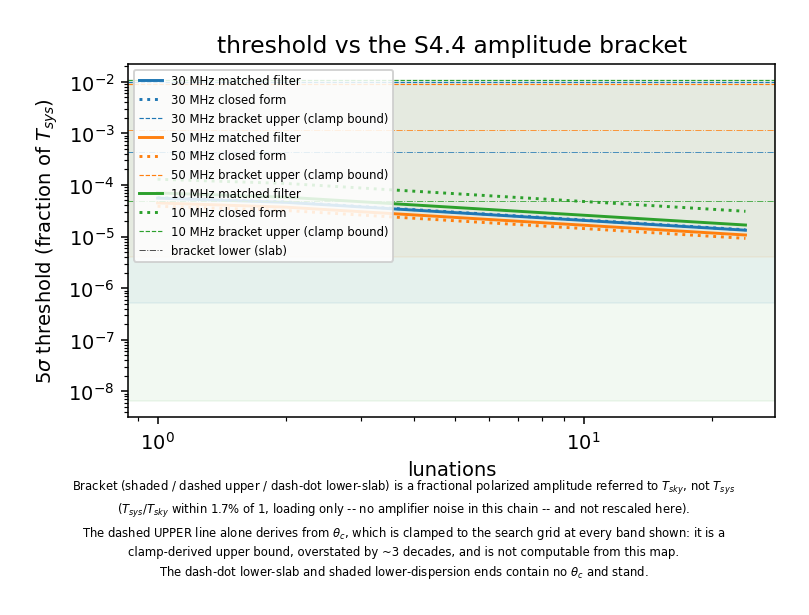

| band | matched filter | closed form | ratio |
|---|---|---|---|
| 30 MHz | 1.33e-05 | 1.35e-05 | 0.980 |
| 50 MHz | 1.07e-05 | 9.23e-06 | 1.161 |
| 10 MHz | 1.67e-05 | 3.09e-05 | 0.542 |

_Ratio > 1 means the matched filter is the WORSE (higher) threshold. The closed form's fixed coherence bandwidth describes the real signal covariance well at 30 MHz and poorly at the other two bands, in opposite directions — which is why it is a sanity check on the matched filter and not a bound on it._

In [11]:
show(sp.fig_sensitivity(s, d))

display(table(
    [(f"{b:.0f} MHz", f"{s['A_mf'][i, i24]:.3g}", f"{s['A_closed'][i, i24]:.3g}",
      f"{s['A_mf'][i, i24] / s['A_closed'][i, i24]:.3f}")
     for i, b in enumerate(BANDS)],
    ["band", "matched filter", "closed form", "ratio"],
))
display(Markdown(
    "_Ratio > 1 means the matched filter is the WORSE (higher) "
    "threshold. The closed form's fixed coherence bandwidth describes "
    "the real signal covariance well at 30 MHz and poorly at the other "
    "two bands, in opposite directions — which is why it is a sanity "
    "check on the matched filter and not a bound on it._"
))

## 12. What this map cannot decide

Both of these are limitations of the inputs, not of the machinery, and
both are stated in `docs/measurement-model.md` §12 rather than left
for a reader to discover.

**(a) The bracket's upper end.** `coherence_angle` clamps at the lower
edge of its search grid at every band in both arms. The clamp
*overstates*: it returns the grid edge when the root lies below it, so
a clamped return is an upper bound on $\theta_c$, and `upper` inherits
that. Widening the grid cannot fix it — the root sits roughly three
decades below `faraday2020v2`'s own nside-512 pixel scale, so a wider
grid would extrapolate $D \propto \theta^2$ rather than measure. A
$\theta^2$ extrapolation gives 7.1e-6 at 30 MHz, which is *below*
`lower_slab`: the bracket inverts, which is itself the proof the
extrapolation is not quotable. **The incoherent-patch upper bound is
not determinable from this map** and must be quoted as such, never as
~1e-2.

**(b) Sky domination at 50 MHz.** `T_sys/T_sky` below is
$1 + T_{\rm loading}/T_{\rm sky}$ and nothing more — the luseepy chain
carries no amplifier noise, and `step5_sensitivity.py --t-amp`
defaults to 0. It is a genuine **lower bound**, not a computed
sky-domination check. Re-run with `--t-amp` when the collaboration
supplies a receiver noise temperature.

A third item, for completeness: the acceptance gates in §2(a) do not
test the identity in §2(b), and the identity in §2(b) does not
demonstrate that the sky is incoherent. Both gate docstrings say so.

In [12]:
rows = []
for ib, band in enumerate(BANDS):
    th = float(d["theta_c"][ib])
    rows.append((
        f"{band:.0f} MHz",
        f"{np.degrees(th):.3f}°",
        "**clamped**" if bool(d["theta_c_clamped"][ib]) else "measured",
        f"{d['bracket'][ib, 0]:.2g}",
        f"{d['bracket'][ib, 1]:.2g}",
        f"{d['bracket'][ib, 2]:.2g}",
        f"{s['tsys_over_tsky'][ib]:.4f}",
    ))
display(table(rows, ["band", "theta_c", "status", "upper (unusable)",
                     "lower_slab", "lower_dispersion", "T_sys/T_sky"]))
display(Markdown(
    f"_theta_c is identical across bands at the grid edge "
    f"({np.degrees(float(d['theta_c'][0])):.1f}°) — the signature of a "
    f"clamp, not a measurement. Loading is a "
    f"≤{100 * (s['tsys_over_tsky'].max() - 1):.1f}% correction, so the "
    f"S4.10 scale-up is negligible; amplifier noise is the open term._"
))

| band | theta_c | status | upper (unusable) | lower_slab | lower_dispersion | T_sys/T_sky |
|---|---|---|---|---|---|---|
| 30 MHz | 0.200° | **clamped** | 0.0099 | 0.00043 | 5.2e-07 | 1.0044 |
| 50 MHz | 0.200° | **clamped** | 0.009 | 0.0012 | 4e-06 | 1.0170 |
| 10 MHz | 0.200° | **clamped** | 0.011 | 5e-05 | 6.4e-09 | 1.0006 |

_theta_c is identical across bands at the grid edge (0.2°) — the signature of a clamp, not a measurement. Loading is a ≤1.7% correction, so the S4.10 scale-up is negligible; amplifier noise is the open term._

## 13. Reproducing this

The `.npz` products are gitignored — regenerable, and 25 MB each — so
this notebook ships with its outputs committed. To rebuild them from
scratch you need `data/` (the 631 MB BGL_v16 response, the Haslam and
WMAP K maps, and `faraday2020v2.hdf5`). Run heavy jobs under a cgroup
on physical memory and report peak RSS:

```bash
systemd-run --user --scope -q -p MemoryMax=10G -- \
    uv run python scripts/step5_instrument_envelope.py \
    > $PWD/generated_data/step5_envelope.log 2>&1

systemd-run --user --scope -q -p MemoryMax=10G -- \
    uv run python scripts/step5_template.py --lst 128 \
    > $PWD/generated_data/step5_template.log 2>&1

systemd-run --user --scope -q -p MemoryMax=10G -- \
    uv run python scripts/step5_template.py --lst 128 --arm two-port \
    > $PWD/generated_data/step5_template_two_port.log 2>&1

uv run python scripts/step5_sensitivity.py \
    > $PWD/generated_data/step5_sensitivity.log 2>&1

uv run python scripts/step5_plots.py      # the six PDFs in report/figures/
```

Then re-execute this notebook:

```bash
uv run jupyter nbconvert --to notebook --execute --inplace \
    notebooks/faraday_delay_template.ipynb
```

### Which test pins which claim

| claim | test |
|---|---|
| shape stable under refinement | `test_dispersion_gates.py::test_gate1_shape_invariance_under_refinement` |
| shape stable under null rotation | `test_dispersion_gates.py::test_gate2_shape_invariance_under_null_rotation` |
| delay power = weighted depth distribution (1.069) | `test_dispersion_gates.py::test_delay_power_equals_the_weighted_depth_distribution` |
| converged-regime control through the NUFFT | `test_dispersion_gates.py::test_converged_regime_points_match_direct_sum` |
| depth-horizon table | `test_dispersion.py::test_depth_horizon_pins_the_s46_table` |
| RMSF widths and convention | `test_dispersion.py::test_boxcar_rmsf_widths` |
| NUFFT beats FFT on a single depth | `test_dispersion.py::test_nufft_beats_fft_on_a_single_depth` |
| BH4 window dynamic-range budget | `test_dispersion.py::test_foreground_sidelobe_budget` |
| theta_c clamps below the sampled range | `test_dispersion_geometry.py::test_coherence_angle_clamps_below_the_sampled_range` |
| bracket closed forms | `test_dispersion_geometry.py::test_amplitude_bracket_closed_forms` |
| zoom-bin overlap degrades the threshold | `test_noise.py::test_overlap_correlation_degrades_the_threshold` |
| matched filter, Monte Carlo | `test_noise.py::test_matched_filter_monte_carlo` |
| tail-gate extraction is inert | `test_dispersion_gates.py::test_tail_gate_extraction_is_numerically_inert` |

### See also

- `report/delay_template/delay_template.tex` — the write-up, with the
  derivations behind every formula used here (`cd report/delay_template && make`)
- `docs/measurement-model.md` §9–§12 — the physics behind every claim here
- `PROGRESS.md` — the Step 5b ledger, including numbers this notebook does not plot
- the `audit-2026-08-18` tag — the refuted diffuse results and `report.tex`